In [1]:
%load_ext autoreload
%autoreload 2

from seek_code import SEEK
from backbone import Backbone
from retrieval import Retrieval
from projector import Projector
from data_handler import EleHandler
from concept_head_tunneled import ConceptHeadTunneled, categorical_CE_loss, CrossedHeadNN, MultiHeadNN
from pathlib import Path


from torch.utils.data import DataLoader, Subset

/data/vision/beery/scratch/antoine/micromamba/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
code = 'ConceptDistance'


dataset = EleHandler(subset='IDI_6')
train_indices, test_indices = dataset.split_perpendicular_to_elephants_and_encounters(split_sizes=[0.5,0.5], hour_delta = 0.2)

train_subset = Subset(dataset, train_indices)
test_subset = Subset(dataset, test_indices)

train_loader = DataLoader(train_subset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False)

In [5]:
MD_for_concepts = Backbone(model_name="MegaDescriptor", pretraining="MD_finetuned_w", experiment_code=code)
MD_for_concepts.unfreeze()

r = Retrieval(experiment_code=code)
r.evaluate_model(MD_for_concepts, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False)

MD_for_concepts.unfreeze()
concept_head = ConceptHeadTunneled(loss=categorical_CE_loss, print_every=1, experiment_code = code, layer = CrossedHeadNN(), reset_weights=True)
concept_head.train(train_loader, test_loader, backbone = MD_for_concepts, num_epochs=35, predict_ele_SEEK = True)
concept_head.test(test_loader, backbone = MD_for_concepts, predict_ele_SEEK = True)

r.evaluate_model(MD_for_concepts, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False)
r.evaluate_model(concept_head, ba= MD_for_concepts, train_loader=train_loader, test_loader=test_loader, show_matches=False, show_plot=False, show_tsne=False)

/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

evaluating backbone
Train Recalls:
Recall@1: 53.15%
Recall@5: 75.01%
Recall@10: 82.89%
Recall@20: 89.10%
Recall@100: 97.83%
Test Recalls:
Recall@1: 38.39%
Recall@5: 54.23%
Recall@10: 60.40%
Recall@20: 66.57%
Recall@100: 83.70%
Training ConceptHead for 35 epochs, reseting weights, and the backbone parameters are, True  concept head parameters are  True
Epoch 1/35 - Train Loss: 19.2038, Val Loss: 15.0503 - Train Acc: 51.29%, Val Acc: 75.22% - Train whole-code: 0.05%, Val whole-code: 0.74% - Train left ear: 41.78%, Val left ear: 65.31% - Train right ear: 43.68%, Val right ear: 63.42%
Epoch 2/35 - Train Loss: 12.9227, Val Loss: 10.4089 - Train Acc: 74.98%, Val Acc: 76.33% - Train whole-code: 0.40%, Val whole-code: 0.37% - Train left ear: 65.15%, Val left ear: 66.27% - Train right ear: 63.72%, Val right ear: 66.01%
Epoch 3/35 - Train Loss: 10.5619, Val Loss: 9.7650 - Train Acc: 75.91%, Val Acc: 76.34% - Train whole-code: 0.71%, Val whole-code: 0.97% - Train left ear: 66.32%, Val left ear: 6

100%|██████████| 31/31 [00:12<00:00,  2.39it/s]


collecting concepts from concept head


100%|██████████| 21/21 [00:09<00:00,  2.29it/s]


Train Recalls:
Recall@1: 5.10%
Recall@5: 11.56%
Recall@10: 17.62%
Recall@20: 26.60%
Recall@100: 65.27%
Test Recalls:
Recall@1: 1.45%
Recall@5: 4.11%
Recall@10: 6.02%
Recall@20: 9.98%
Recall@100: 27.95%


In [6]:
MD_finetuned = Backbone(model_name="MegaDescriptor", pretraining="MD_finetuned_w", experiment_code=code)
MD_finetuned.unfreeze()

gallery_embeddings, gallery_labels = MD_finetuned.collect_embeddings(train_loader)
query_embeddings, query_labels = MD_finetuned.collect_embeddings(test_loader)

gallery_concepts, gallery_labels_2 = concept_head.collect_embeddings(train_loader, MD_for_concepts, intervention_fn = None, aggregate_seeks=False)
query_concepts, query_labels_2 = concept_head.collect_embeddings(test_loader, MD_for_concepts, intervention_fn = None, aggregate_seeks=False)

gallery_predicted_aggregated_concepts, gallery_labels = concept_head.collect_embeddings(train_loader, MD_for_concepts, intervention_fn = None, aggregate_seeks=True)
query_predicted_aggregated_concepts, query_labels = concept_head.collect_embeddings(test_loader, MD_for_concepts, intervention_fn = None, aggregate_seeks=True)

gallery_corrected_concepts, gallery_labels = concept_head.collect_embeddings(train_loader, MD_for_concepts, intervention_fn = SEEK.perfect_correction, aggregate_seeks=False)
query_corrected_concepts, query_labels = concept_head.collect_embeddings(test_loader, MD_for_concepts, intervention_fn = SEEK.perfect_correction, aggregate_seeks=False)

gallery_oracle_concepts, gallery_labels = concept_head.collect_embeddings(train_loader, MD_for_concepts, intervention_fn = SEEK.oracle_correction, aggregate_seeks=False)
query_oracle_concepts, query_labels = concept_head.collect_embeddings(test_loader, MD_for_concepts, intervention_fn = SEEK.oracle_correction, aggregate_seeks=False)

galley_aggregated_concepts, gallery_labels = concept_head.collect_embeddings(train_loader, MD_for_concepts, intervention_fn = SEEK.perfect_correction, aggregate_seeks=True)
query_aggregated_concepts, query_labels = concept_head.collect_embeddings(test_loader, MD_for_concepts, intervention_fn = SEEK.perfect_correction, aggregate_seeks=True)

test_similarity_matrix = r.cosine_similarity_matrix(query_embeddings, gallery_embeddings)
gallery_corrected_concepts = gallery_corrected_concepts.cpu()

collecting concepts from concept head


100%|██████████| 31/31 [00:13<00:00,  2.32it/s]


collecting concepts from concept head


100%|██████████| 21/21 [00:09<00:00,  2.27it/s]


collecting concepts from concept head


...

100%|██████████| 21/21 [00:08<00:00,  2.38it/s]


collecting concepts from concept head


100%|██████████| 31/31 [00:13<00:00,  2.33it/s]


collecting concepts from concept head


100%|██████████| 21/21 [00:08<00:00,  2.42it/s]


In [15]:
import torch
top_k_indices = torch.topk(test_similarity_matrix, k=1, dim=1, largest=True).indices
top_k_indices = top_k_indices.cpu()
top_k_consine_sim = torch.topk(test_similarity_matrix, k=1, dim=1, largest=True).values

# Count the number of relevant items in the top-k results for each query
total_relevant = 0
matches = []
ground_truth = []
retrieved = []

true_correct_concept = []
retrieved_correctconcept = []

true_predicted_concept = []
retrieved_predicted_concept = []
true_oracle_concept = []
retrieved_oracle_concept = []
true_aggregated_concept = []
retrieved_aggregated_concept = []
true_predicted_aggregated_concept = []
retrieved_predicted_aggregated_concept = []


for i, query_label in enumerate(query_labels):
    #print('top_k_indices', top_k_indices[i])
    top_k_labels = gallery_labels[top_k_indices[i]]
    #print('top_k_labels', top_k_labels)
    #print('query_label', query_label)
    ground_truth.append(query_label)
    retrieved.append(top_k_labels)
    
    true_correct_concept.append(query_corrected_concepts[i])
    retrieved_correctconcept.append(gallery_corrected_concepts[top_k_indices[i]])

    true_predicted_concept.append(query_concepts[i])
    retrieved_predicted_concept.append(gallery_concepts[top_k_indices[i]])

    true_oracle_concept.append(query_oracle_concepts[i])
    retrieved_oracle_concept.append(gallery_oracle_concepts[top_k_indices[i]])

    true_aggregated_concept.append(query_aggregated_concepts[i])
    retrieved_aggregated_concept.append(galley_aggregated_concepts[top_k_indices[i]])

    true_predicted_aggregated_concept.append(query_predicted_aggregated_concepts[i])
    retrieved_predicted_aggregated_concept.append(gallery_predicted_aggregated_concepts[top_k_indices[i]])

    # Count if the query_label appears in the top-k labels
    if query_label in [top_k_labels]:
        #print(query_label, top_k_labels)
        total_relevant += 1
        matches.append(1)
    else:
        matches.append(0)

In [20]:
def concept_distances(true_concepts, retrieved_concepts):

    concept_acc_avg = [concept_head.accuracy_fn(true_concepts[i].unsqueeze(0), retrieved_concepts[i])['average'] for i in range(len(true_concepts))]
    concept_acc_left_ear = [concept_head.accuracy_fn(true_concepts[i].unsqueeze(0), retrieved_concepts[i])['left_ear'] for i in range(len(true_concepts))]
    concept_norms = [torch.norm(true_concepts[i] - retrieved_concepts[i].squeeze(0), p=1).item()/2 for i in range(len(true_concepts))]
    predicted_concept_norms = [torch.norm(true_concepts[i] - retrieved_concepts[i].squeeze(0), p=1).item()/2 for i in range(len(true_concepts))]
    big_errors = [concept_head.accuracy_fn(true_concepts[i].unsqueeze(0), retrieved_concepts[i])['big_errors'] for i in range(len(true_concepts))]
    return concept_acc_avg, concept_acc_left_ear, concept_norms, predicted_concept_norms, big_errors

concept_acc_avg_predicted, concept_acc_left_ear_predicted, concept_norms_predicted, predicted_concept_norms_predicted, big_errors_predicted = concept_distances(true_predicted_concept, retrieved_predicted_concept)
concept_acc_avg_corrected, concept_acc_left_ear_corrected, concept_norms_corrected, predicted_concept_norms_corrected, big_errors_corrected = concept_distances(true_correct_concept, retrieved_correctconcept)
concept_acc_avg_oracle, concept_acc_left_ear_oracle, concept_norms_oracle, predicted_concept_norms_oracle, big_errors_oracle = concept_distances(true_oracle_concept, retrieved_oracle_concept)
concept_acc_avg_aggregated, concept_acc_left_ear_aggregated, concept_norms_aggregated, predicted_concept_norms_aggregated, big_errors_aggregated = concept_distances(true_aggregated_concept, retrieved_aggregated_concept)
concept_acc_avg_predicted_aggregated, concept_acc_left_ear_predicted_aggregated, concept_norms_predicted_aggregated, predicted_concept_norms_predicted_aggregated, big_errors_predicted_aggregated = concept_distances(true_predicted_aggregated_concept, retrieved_predicted_aggregated_concept)

# For Retrieval on corrected Subject SEEK

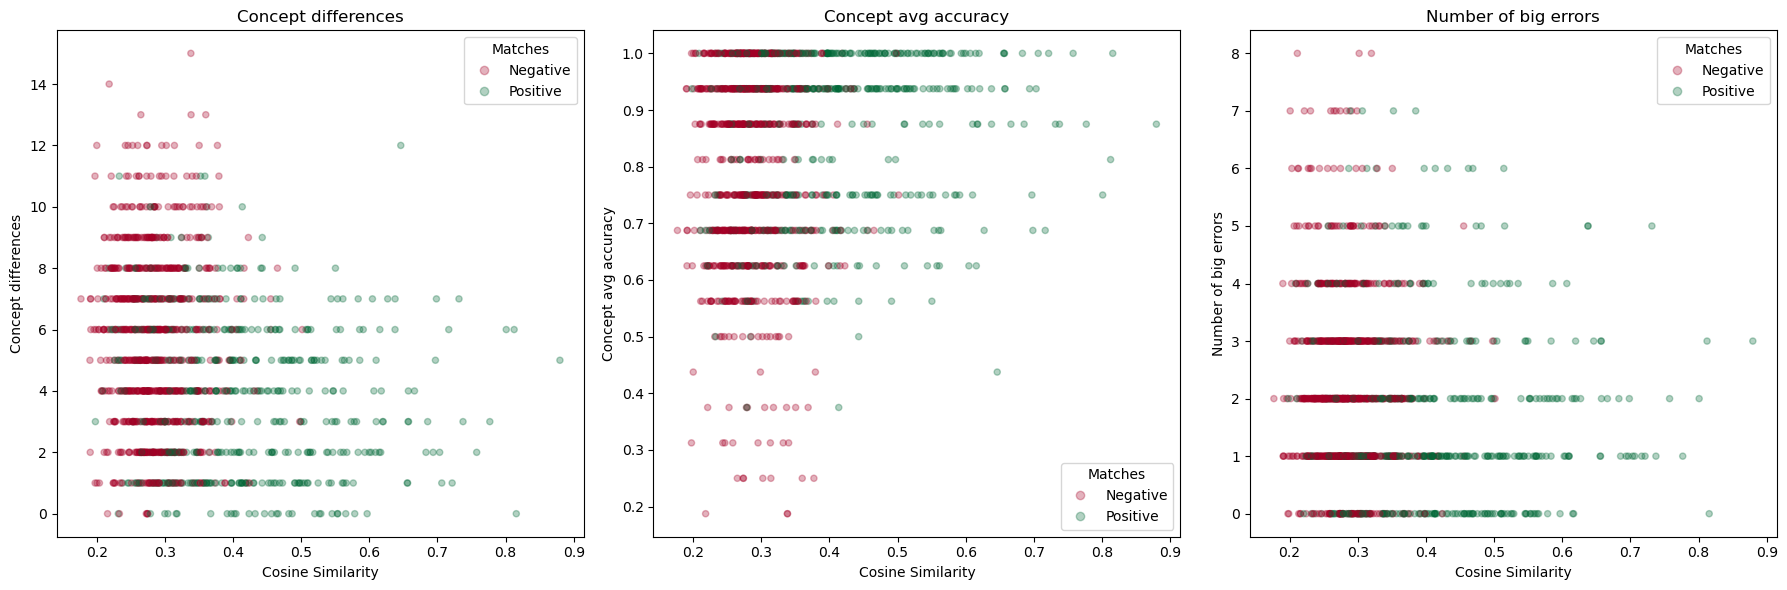

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
scatter = plt.scatter(top_k_consine_sim.cpu(), concept_norms_corrected, c=matches, cmap='RdYlGn', alpha=0.3, marker='o', s=20)
plt.xlabel('Cosine Similarity')
plt.ylabel('Concept differences')
plt.title('Concept differences')
plt.legend(handles=scatter.legend_elements()[0], labels=['Negative', 'Positive'], title="Matches")

plt.subplot(1, 3, 2)
scatter = plt.scatter(top_k_consine_sim.cpu(), concept_acc_avg_corrected, c=matches, cmap='RdYlGn', alpha=0.3, marker='o', s=20)
plt.xlabel('Cosine Similarity')
plt.ylabel('Concept avg accuracy')
plt.title('Concept avg accuracy')
plt.legend(handles=scatter.legend_elements()[0], labels=['Negative', 'Positive'], title="Matches")

plt.subplot(1, 3, 3)
scatter = plt.scatter(top_k_consine_sim.cpu(), big_errors_corrected, c=matches, cmap='RdYlGn', alpha=0.3, marker='o', s=20)
plt.xlabel('Cosine Similarity')
plt.ylabel('Number of big errors')
plt.title('Number of big errors')
plt.legend(handles=scatter.legend_elements()[0], labels=['Negative', 'Positive'], title="Matches")

plt.tight_layout()
plt.show()

## With Aggregated True subject SEEK 

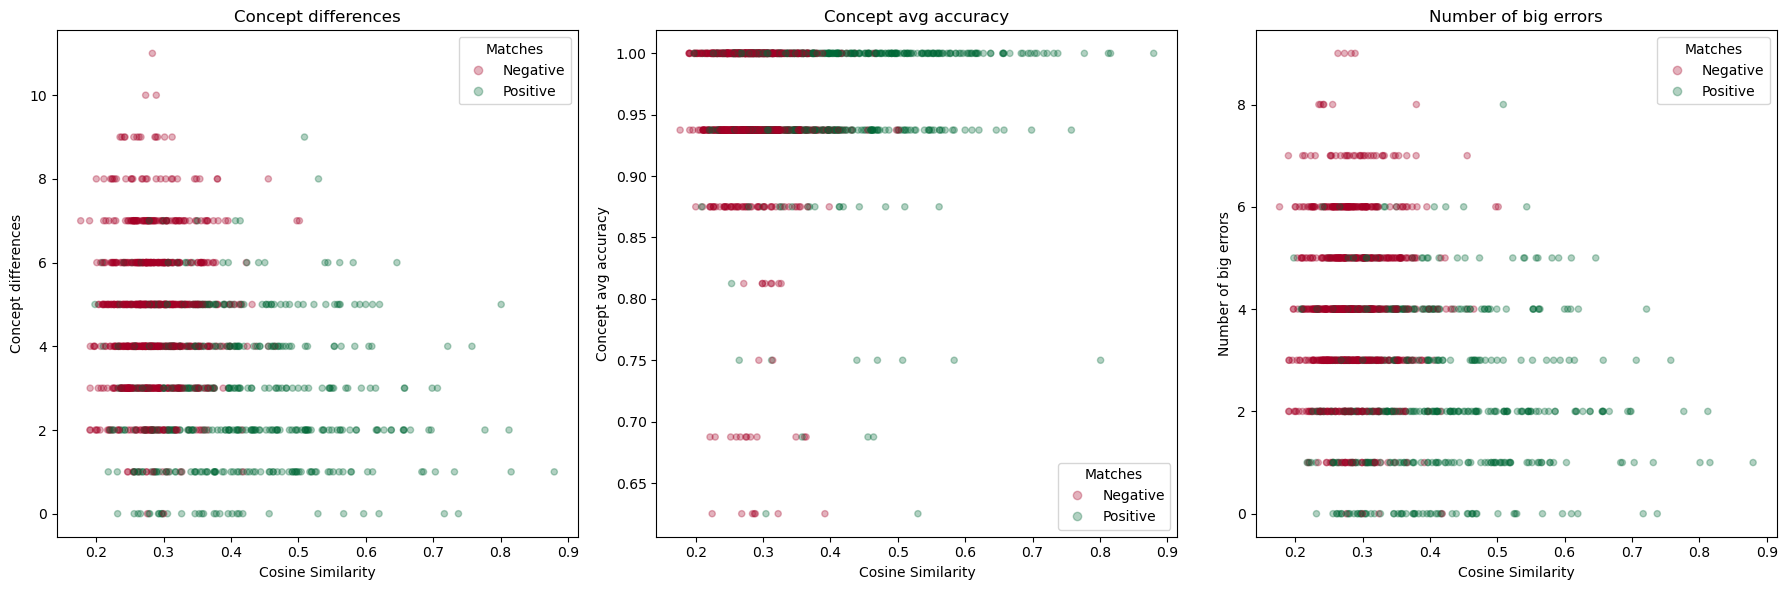

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
scatter = plt.scatter(top_k_consine_sim.cpu(), concept_norms_aggregated, c=matches, cmap='RdYlGn', alpha=0.3, marker='o', s=20)
plt.xlabel('Cosine Similarity')
plt.ylabel('Concept differences')
plt.title('Concept differences')
plt.legend(handles=scatter.legend_elements()[0], labels=['Negative', 'Positive'], title="Matches")

plt.subplot(1, 3, 2)
scatter = plt.scatter(top_k_consine_sim.cpu(), concept_acc_avg_aggregated, c=matches, cmap='RdYlGn', alpha=0.3, marker='o', s=20)
plt.xlabel('Cosine Similarity')
plt.ylabel('Concept avg accuracy')
plt.title('Concept avg accuracy')
plt.legend(handles=scatter.legend_elements()[0], labels=['Negative', 'Positive'], title="Matches")

plt.subplot(1, 3, 3)
scatter = plt.scatter(top_k_consine_sim.cpu(), big_errors_aggregated, c=matches, cmap='RdYlGn', alpha=0.3, marker='o', s=20)
plt.xlabel('Cosine Similarity')
plt.ylabel('Number of big errors')
plt.title('Number of big errors')
plt.legend(handles=scatter.legend_elements()[0], labels=['Negative', 'Positive'], title="Matches")

plt.tight_layout()
plt.show()

## With Predicted subject SEEK 

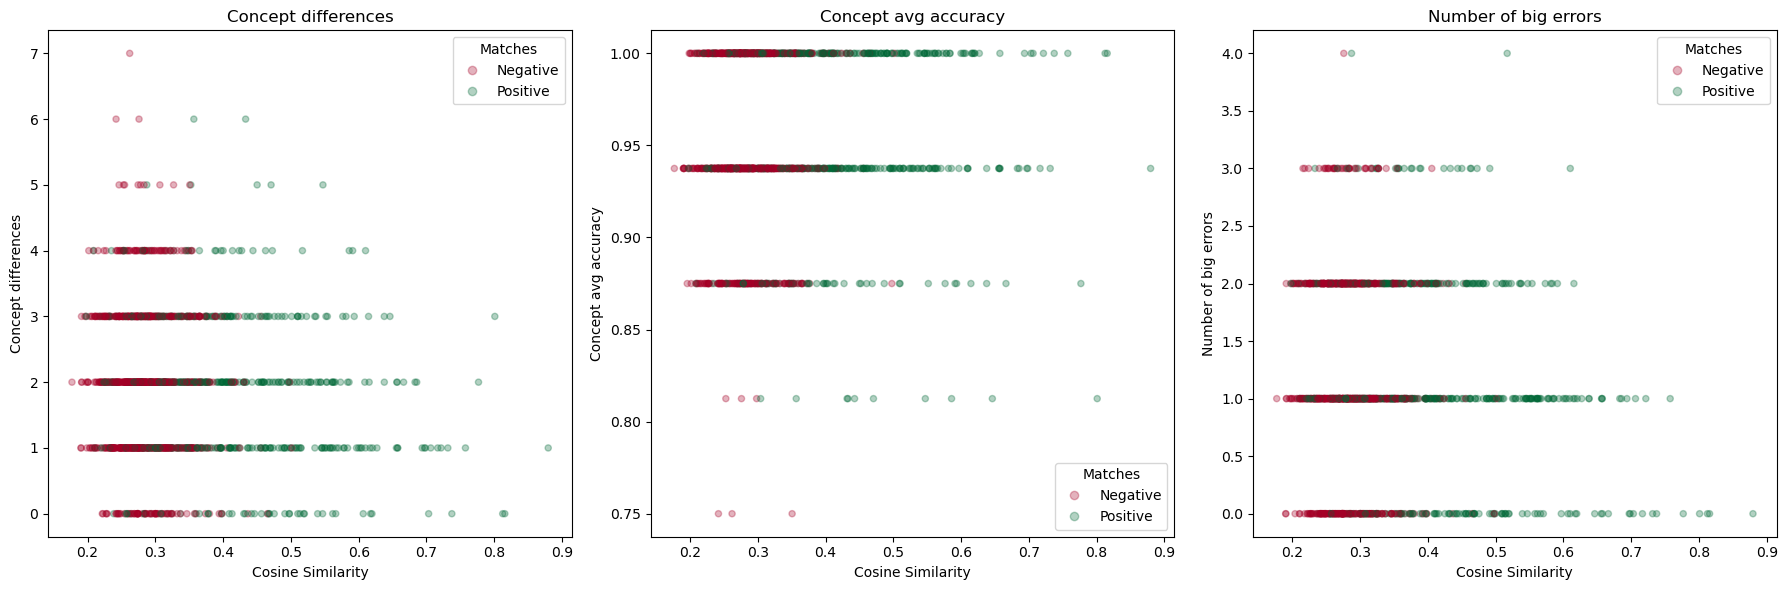

In [34]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
scatter = plt.scatter(top_k_consine_sim.cpu(), concept_norms_predicted, c=matches, cmap='RdYlGn', alpha=0.3, marker='o', s=20)
plt.xlabel('Cosine Similarity')
plt.ylabel('Concept differences')
plt.title('Concept differences')
plt.legend(handles=scatter.legend_elements()[0], labels=['Negative', 'Positive'], title="Matches")

plt.subplot(1, 3, 2)
scatter = plt.scatter(top_k_consine_sim.cpu(), concept_acc_avg_predicted, c=matches, cmap='RdYlGn', alpha=0.3, marker='o', s=20)
plt.xlabel('Cosine Similarity')
plt.ylabel('Concept avg accuracy')
plt.title('Concept avg accuracy')
plt.legend(handles=scatter.legend_elements()[0], labels=['Negative', 'Positive'], title="Matches")

plt.subplot(1, 3, 3)
scatter = plt.scatter(top_k_consine_sim.cpu(), big_errors_predicted, c=matches, cmap='RdYlGn', alpha=0.3, marker='o', s=20)
plt.xlabel('Cosine Similarity')
plt.ylabel('Number of big errors')
plt.title('Number of big errors')
plt.legend(handles=scatter.legend_elements()[0], labels=['Negative', 'Positive'], title="Matches")

plt.tight_layout()
plt.show()

## Predicted aggregated image_seek

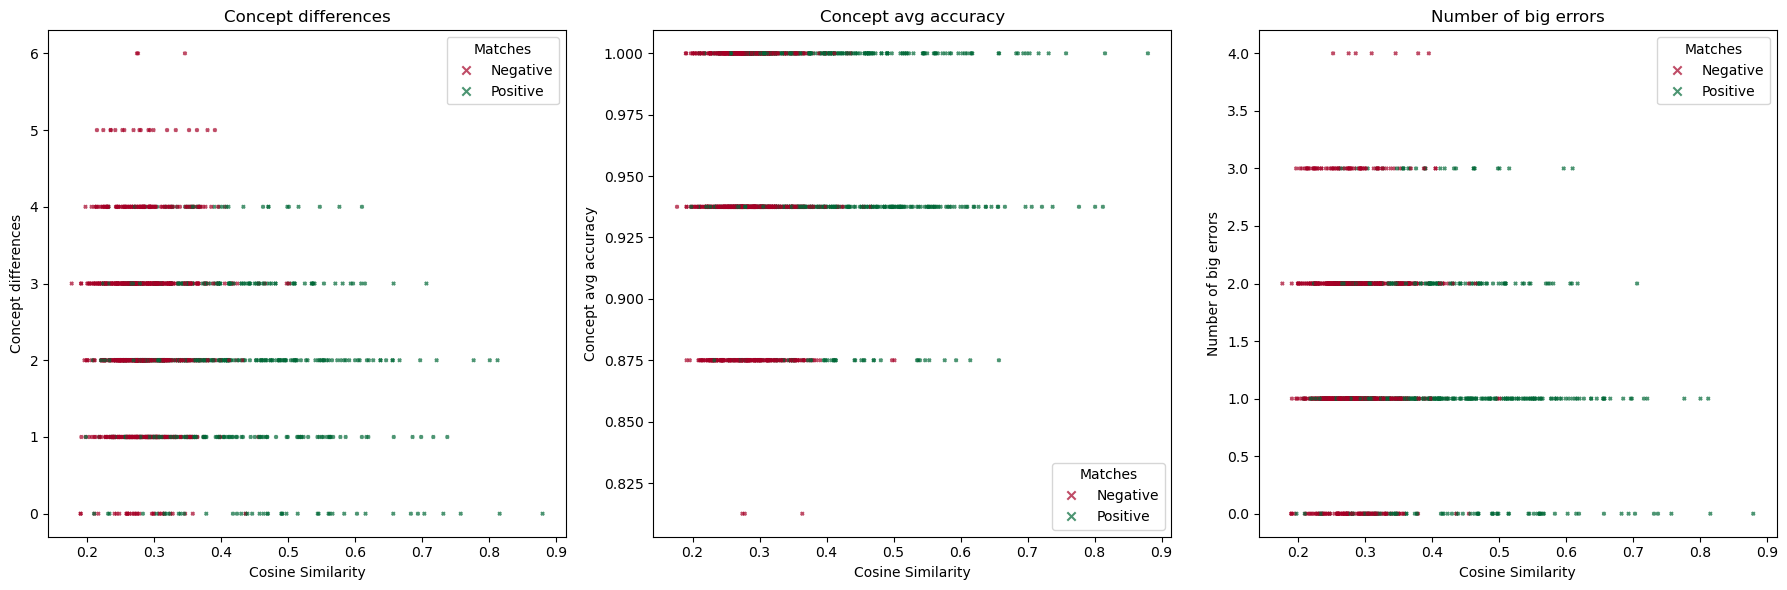

In [35]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
scatter = plt.scatter(top_k_consine_sim.cpu(), concept_norms_predicted_aggregated, c=matches, cmap='RdYlGn', alpha=0.7, marker='x', s=5)
plt.xlabel('Cosine Similarity')
plt.ylabel('Concept differences')
plt.title('Concept differences')
plt.legend(handles=scatter.legend_elements()[0], labels=['Negative', 'Positive'], title="Matches")

plt.subplot(1, 3, 2)
scatter = plt.scatter(top_k_consine_sim.cpu(), concept_acc_avg_predicted_aggregated, c=matches, cmap='RdYlGn', alpha=0.7, marker='x', s=5)
plt.xlabel('Cosine Similarity')
plt.ylabel('Concept avg accuracy')
plt.title('Concept avg accuracy')
plt.legend(handles=scatter.legend_elements()[0], labels=['Negative', 'Positive'], title="Matches")

plt.subplot(1, 3, 3)
scatter = plt.scatter(top_k_consine_sim.cpu(), big_errors_predicted_aggregated, c=matches, cmap='RdYlGn', alpha=0.7, marker='x', s=5)
plt.xlabel('Cosine Similarity')
plt.ylabel('Number of big errors')
plt.title('Number of big errors')
plt.legend(handles=scatter.legend_elements()[0], labels=['Negative', 'Positive'], title="Matches")

plt.tight_layout()
plt.show()